# Setup Connections

In [15]:
from google.cloud import bigquery
from google.colab import auth
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

auth.authenticate_user()
PROJECT_ID = "stickearn-test-502018"
client = bigquery.Client(project=PROJECT_ID)

# Mobility Activity

## Activity Distribution per Hour

In [16]:
query_hourly = """
SELECT
  EXTRACT(HOUR FROM datetime) AS hour_of_day,
  COUNT(*) AS total_records,
  COUNT(DISTINCT id) AS unique_devices
FROM `stickearn-test-502018.stickearn_test.master_mobility`
GROUP BY hour_of_day
ORDER BY hour_of_day
"""
df_hourly = client.query(query_hourly).to_dataframe()

query_hourly_os = """
SELECT
  EXTRACT(HOUR FROM datetime) AS hour_of_day,
  device_os,
  COUNT(*) AS total_records,
  COUNT(DISTINCT id) AS unique_devices
FROM `stickearn-test-502018.stickearn_test.master_mobility`
GROUP BY hour_of_day, device_os
ORDER BY hour_of_day, device_os
"""
df_hourly_os = client.query(query_hourly_os).to_dataframe()

### Chart 1 (Total records & Unique Device per Hour)

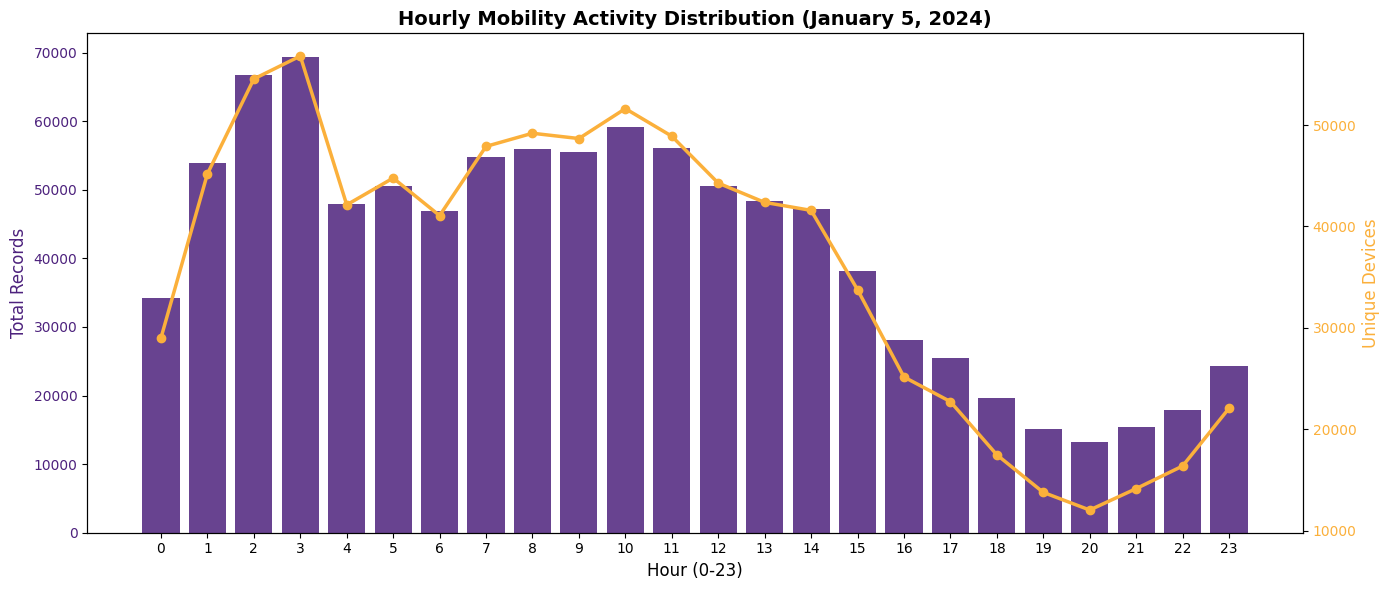

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#4D227D' # Deep Purple
color2 = '#FBB03B' # Marigold/Warm Yellow

ax1.bar(df_hourly['hour_of_day'], df_hourly['total_records'], color=color1, alpha=0.85, label='Total Records')
ax1.set_xlabel('Hour (0-23)', fontsize=12)
ax1.set_ylabel('Total Records', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(df_hourly['hour_of_day'], df_hourly['unique_devices'], color=color2, marker='o', linewidth=2.5, label='Unique Devices')
ax2.set_ylabel('Unique Devices', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Hourly Mobility Activity Distribution (January 5, 2024)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('hourly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 (Breakdown per device_os)

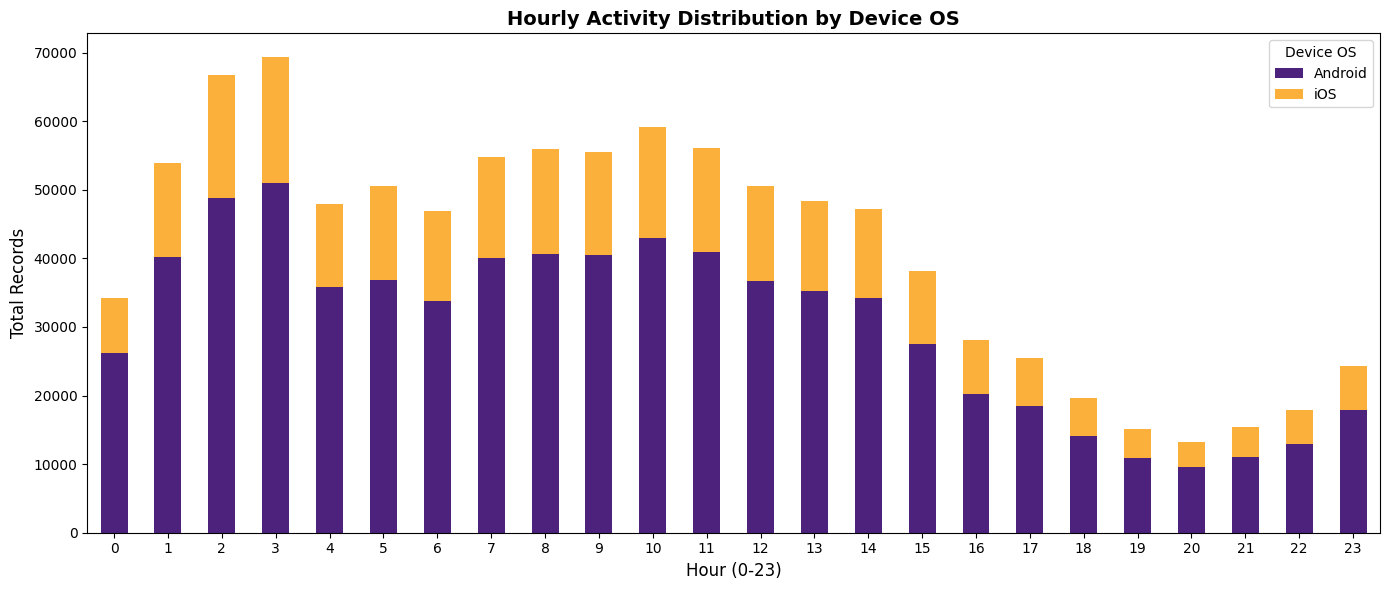

In [18]:
pivot_os = df_hourly_os.pivot(index='hour_of_day', columns='device_os', values='total_records')

fig, ax = plt.subplots(figsize=(14, 6))
pivot_os.plot(kind='bar', stacked=True, ax=ax, color=[color1, color2])
ax.set_xlabel('Hour (0-23)', fontsize=12)
ax.set_ylabel('Total Records', fontsize=12)
ax.set_title('Hourly Activity Distribution by Device OS', fontsize=14, fontweight='bold')
ax.legend(title='Device OS')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('hourly_distribution_by_os.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight Peak Hour

In [19]:
peak_hour = df_hourly.loc[df_hourly['total_records'].idxmax()]
lowest_hour = df_hourly.loc[df_hourly['total_records'].idxmin()]
print(f"Peak hour: hour {int(peak_hour['hour_of_day'])} with {int(peak_hour['total_records'])} records")
print(f"Lowest hour: hour {int(lowest_hour['hour_of_day'])} with {int(lowest_hour['total_records'])} records")

Peak hour: hour 3 with 69337 records
Lowest hour: hour 20 with 13186 records


## Grid Density Heatmap


In [20]:
query_grid = """
SELECT grid_lat, grid_long, point_count, unique_devices
FROM `stickearn-test-502018.stickearn_test.mobility_grid_density`
"""
df_grid = client.query(query_grid).to_dataframe()

### Chart

In [21]:
fig = px.density_mapbox(
    df_grid,
    lat='grid_lat',
    lon='grid_long',
    z='point_count',
    radius=15,
    center=dict(lat=-6.2, lon=106.816),
    zoom=10,
    mapbox_style="carto-positron",
    color_continuous_scale="Turbo",
    title="Density Heatmap - Mobility Points in Jakarta (January 5, 2024)"
)
fig.update_layout(
    width=900, height=700,
    margin=dict(l=0, r=0, t=50, b=0)
)
fig.show()
fig.write_html("mobility_density_heatmap.html")

### Insight

In [22]:
top_grids = df_grid.sort_values('point_count', ascending=False).head(10)
print("\nTop 10 Densest Grids:")
print(top_grids[['grid_lat', 'grid_long', 'point_count', 'unique_devices']].to_string(index=False))


Top 10 Densest Grids:
 grid_lat  grid_long  point_count  unique_devices
   -6.174    106.829        38404           24310
   -6.211    106.845        37765           21951
   -6.173    106.827         8523            5262
   -6.288    106.722         3807            2952
   -6.158    106.837         2278            1262
   -6.164    106.772         1762            1348
   -6.318    106.788         1288             929
   -6.174    106.830         1057             702
   -6.227    106.837          728             473
   -6.211    106.844          708             681


## Outlier

### Outlier Check — Record Count per Device

In [23]:
query_record_count = """
SELECT id, COUNT(*) AS record_count
FROM `stickearn-test-502018.stickearn_test.master_mobility`
GROUP BY id
"""
df_record_count = client.query(query_record_count).to_dataframe()

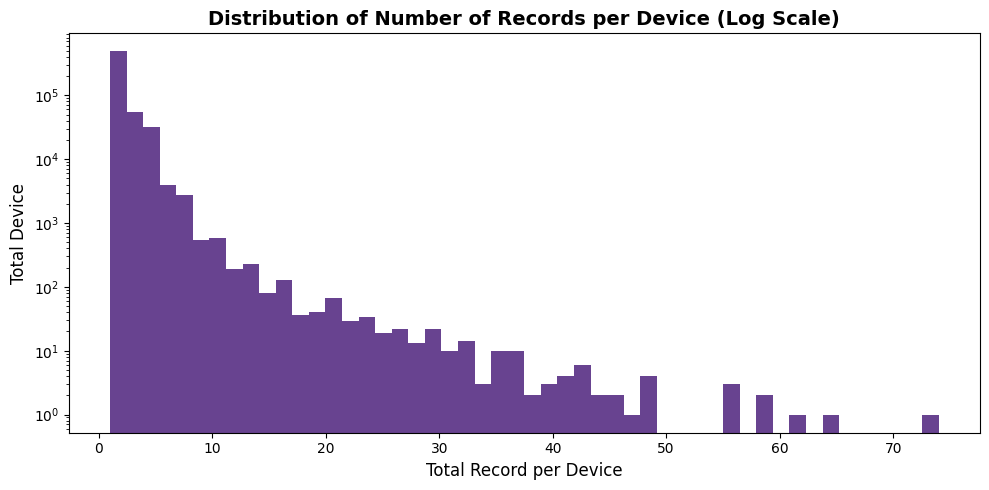

count    581170.0
mean     1.711456
std      1.356228
min           1.0
25%           1.0
50%           1.0
75%           2.0
max          74.0
Name: record_count, dtype: Float64
P95: 4.0
P99: 6.0


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_record_count['record_count'], bins=50, color='#4D227D', alpha=0.85)
ax.set_xlabel('Total Record per Device', fontsize=12)
ax.set_ylabel('Total Device', fontsize=12)
ax.set_title('Distribution of Number of Records per Device (Log Scale)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('record_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_record_count['record_count'].describe())
print(f"P95: {df_record_count['record_count'].quantile(0.95)}")
print(f"P99: {df_record_count['record_count'].quantile(0.99)}")

### Outlier Check — Implied Travel Speed

In [25]:
SPEED_THRESHOLD_KMH = 110

query_speed_check = """
WITH ordered_points AS (
  SELECT
    id, datetime, latitude, longitude,
    LAG(datetime) OVER (PARTITION BY id ORDER BY datetime) AS prev_datetime,
    LAG(latitude) OVER (PARTITION BY id ORDER BY datetime) AS prev_lat,
    LAG(longitude) OVER (PARTITION BY id ORDER BY datetime) AS prev_long
  FROM `stickearn-test-502018.stickearn_test.master_mobility`
),
distance_calc AS (
  SELECT
    id, datetime, prev_datetime, latitude, longitude,
    ST_DISTANCE(ST_GEOGPOINT(longitude, latitude), ST_GEOGPOINT(prev_long, prev_lat)) AS distance_meters,
    TIMESTAMP_DIFF(datetime, prev_datetime, SECOND) AS time_diff_seconds
  FROM ordered_points
  WHERE prev_datetime IS NOT NULL AND TIMESTAMP_DIFF(datetime, prev_datetime, SECOND) > 0
)
SELECT
  id, datetime,
  SAFE_DIVIDE(distance_meters/1000, time_diff_seconds/3600) AS implied_speed_kmh
FROM distance_calc
WHERE SAFE_DIVIDE(distance_meters/1000, time_diff_seconds/3600) > 110
"""
df_anomaly = client.query(query_speed_check).to_dataframe()

In [26]:
print(f"Number of anomalous transitions (>{SPEED_THRESHOLD_KMH} km/h): {len(df_anomaly)}")
print(f"Percentage of total transitions: {len(df_anomaly)/413477*100:.2f}%")

Number of anomalous transitions (>110 km/h): 1187
Percentage of total transitions: 0.29%


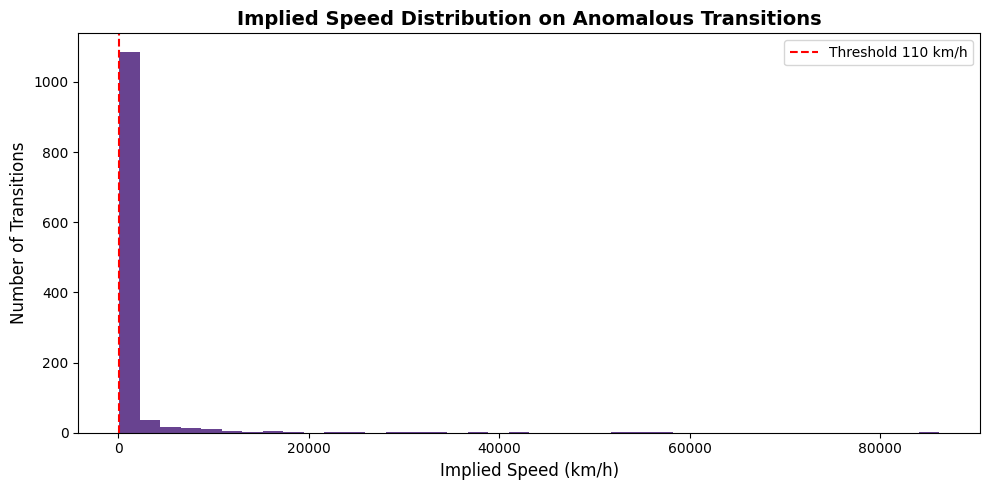

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_anomaly['implied_speed_kmh'], bins=40, color='#4D227D', alpha=0.85)
ax.axvline(SPEED_THRESHOLD_KMH, color='red', linestyle='--', label=f'Threshold {SPEED_THRESHOLD_KMH} km/h')
ax.set_xlabel('Implied Speed (km/h)', fontsize=12)
ax.set_ylabel('Number of Transitions', fontsize=12)
ax.set_title('Implied Speed Distribution on Anomalous Transitions', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outlier_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Exposure per billboard

In [28]:
query_50m = """
SELECT *
FROM `stickearn-test-502018.stickearn_test.exposure_summary_50m`;
"""
df_50m = client.query(query_50m).to_dataframe()

query_100m = """
SELECT *
FROM `stickearn-test-502018.stickearn_test.exposure_summary_100m`;
"""
df_100m = client.query(query_100m).to_dataframe()

In [29]:
df_50m['short_name'] = df_50m['billboard_name'].str[:30]
df_100m['short_name'] = df_100m['billboard_name'].str[:30]

## Bar Chart Top 10


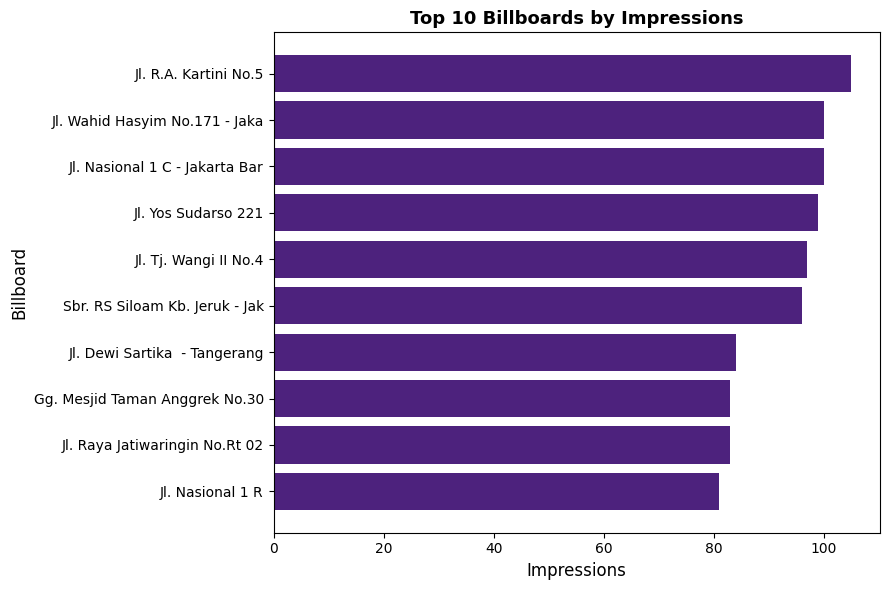

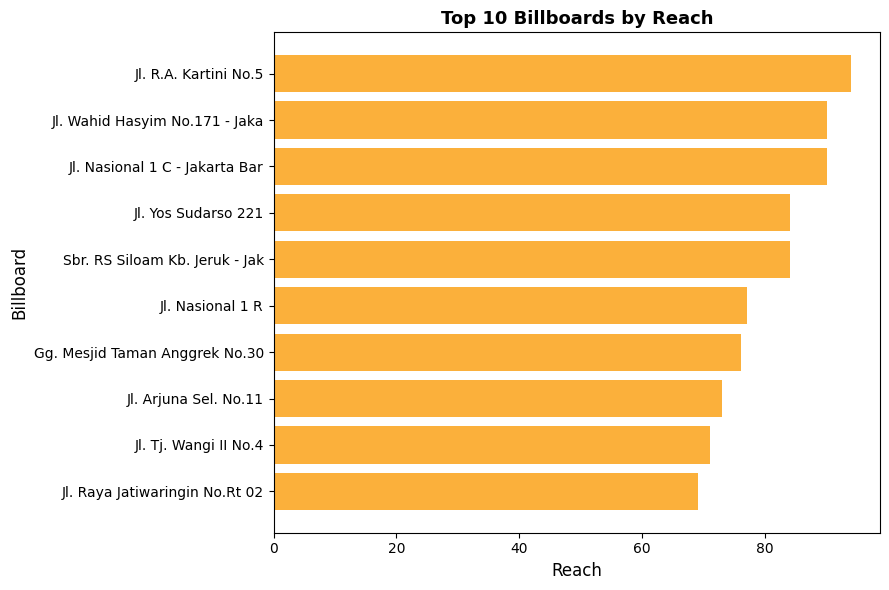

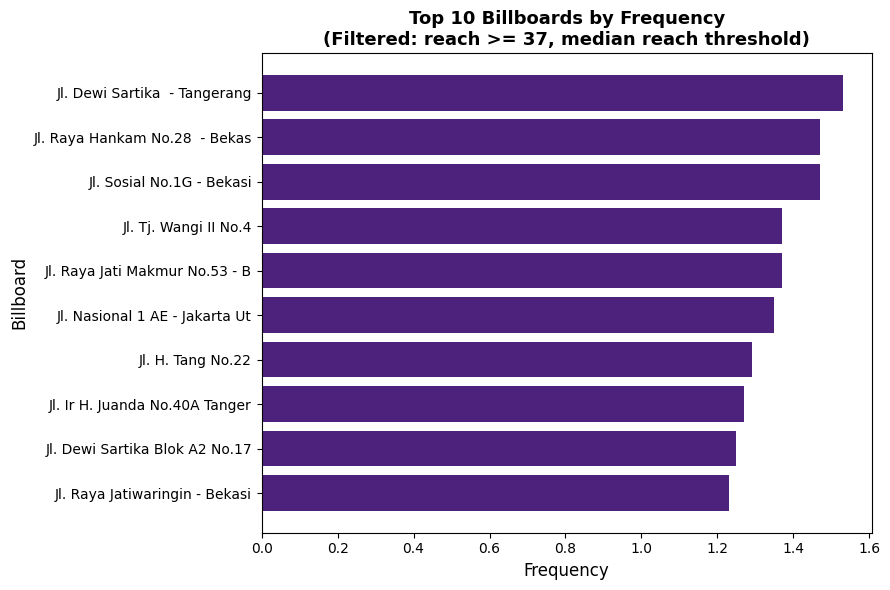

In [30]:
# Fetch pre-aggregated data from BigQuery
query_top10_impressions = """
SELECT billboard_name, impressions, reach, frequency
FROM `stickearn-test-502018.stickearn_test.exposure_summary_100m`
ORDER BY impressions DESC
LIMIT 10
"""
df_top10_impressions = client.query(query_top10_impressions).to_dataframe()


query_top10_reach = """
SELECT billboard_name, impressions, reach, frequency
FROM `stickearn-test-502018.stickearn_test.exposure_summary_100m`
ORDER BY reach DESC
LIMIT 10
"""
df_top10_reach = client.query(query_top10_reach).to_dataframe()


query_top10_frequency = f"""
SELECT billboard_name, impressions, reach, frequency
FROM `stickearn-test-502018.stickearn_test.exposure_summary_100m`
WHERE reach >= 37
ORDER BY frequency DESC
LIMIT 10
"""
df_top10_frequency = client.query(query_top10_frequency).to_dataframe()


# Plotting function
def plot_top10(df, metric, color, filename, subtitle=''):
    df_sorted = df.sort_values(metric).copy()
    df_sorted['short_name'] = df_sorted['billboard_name'].str[:30]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(df_sorted['short_name'], df_sorted[metric], color=color)

    ax.set_xlabel(metric.capitalize(), fontsize=12)
    ax.set_ylabel('Billboard', fontsize=12)

    title = f'Top 10 Billboards by {metric.capitalize()}'
    if subtitle:
        title += f'\n{subtitle}'
    ax.set_title(title, fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# Execute plotting
plot_top10(df_top10_impressions, 'impressions', color1, 'top10_impressions.png')
plot_top10(df_top10_reach, 'reach', color2, 'top10_reach.png')
plot_top10(df_top10_frequency, 'frequency', color1, 'top10_frequency.png',
           subtitle=f'(Filtered: reach >= 37, median reach threshold)')

## Billboard Classification (Reach vs Frequency Scatter)

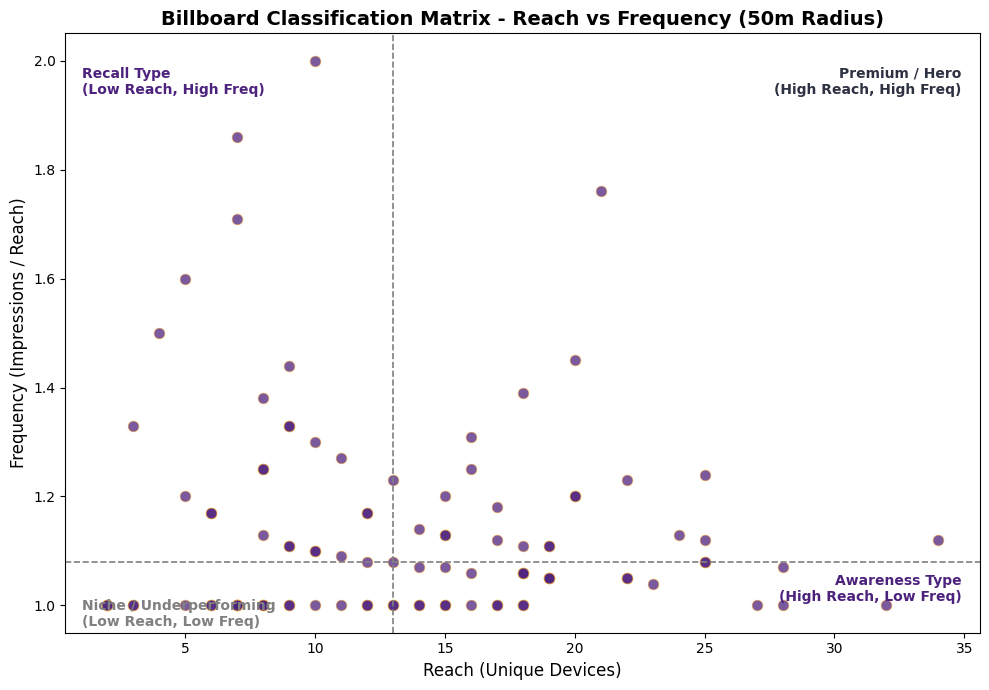

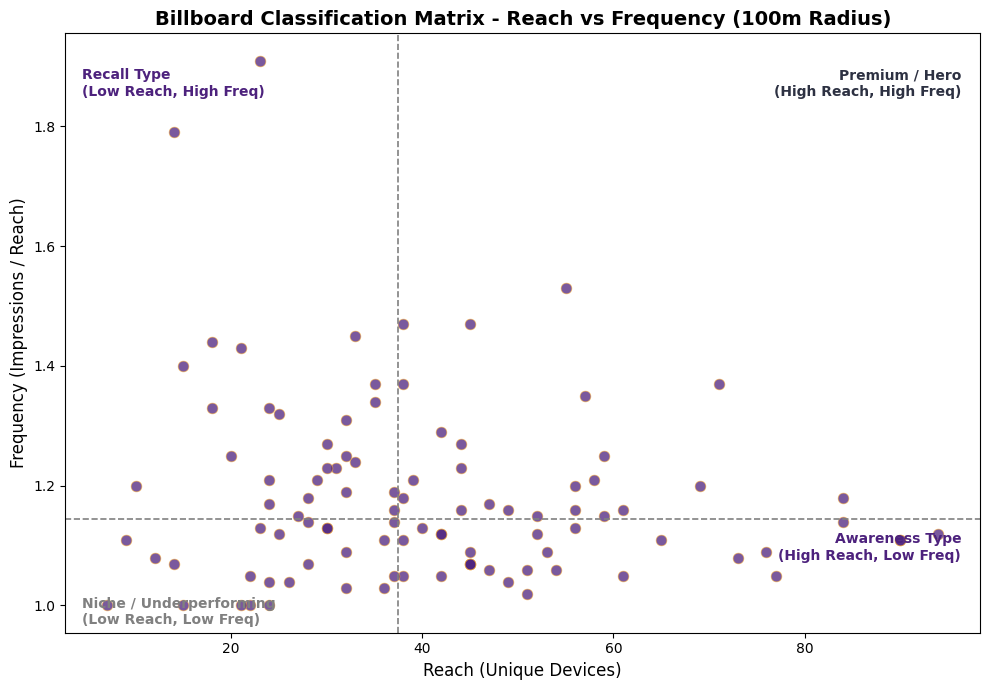

In [31]:
def plot_scatter_classification(df, radius_label, filename):
    reach_median = df['reach'].median()
    freq_median = df['frequency'].median()

    fig, ax = plt.subplots(figsize=(10, 7))

    # Scatter plot
    ax.scatter(df['reach'], df['frequency'], color=color1, alpha=0.75,
               s=60, edgecolor=color2, linewidth=0.5)

    # Median lines dividing the quadrants
    ax.axvline(reach_median, color='gray', linestyle='--', linewidth=1.2)
    ax.axhline(freq_median, color='gray', linestyle='--', linewidth=1.2)

    ax.set_xlabel('Reach (Unique Devices)', fontsize=12)
    ax.set_ylabel('Frequency (Impressions / Reach)', fontsize=12)
    ax.set_title(f'Billboard Classification Matrix - Reach vs Frequency ({radius_label} Radius)',
                 fontsize=14, fontweight='bold')

    # Get axis limits for text placement
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # --- QUADRANT LABELS ---

    # 1. Top-Right: High Reach, High Freq (Premium)
    ax.text(xmax*0.98, ymax*0.97, 'Premium / Hero\n(High Reach, High Freq)',
            ha='right', va='top', fontsize=10, color='#2D3142', fontweight='bold')

    # 2. Bottom-Right: High Reach, Low Freq (Awareness)
    # Changed from 1.02 (above median) to freq_median*0.98 (below median)
    ax.text(xmax*0.98, freq_median*0.98, 'Awareness Type\n(High Reach, Low Freq)',
            ha='right', va='top', fontsize=10, color=color1, fontweight='bold')

    # 3. Top-Left: Low Reach, High Freq (Recall)
    ax.text(xmin + (reach_median-xmin)*0.05, ymax*0.97, 'Recall Type\n(Low Reach, High Freq)',
            ha='left', va='top', fontsize=10, color=color1, fontweight='bold')

    # 4. Bottom-Left: Low Reach, Low Freq (Underperforming)
    ax.text(xmin + (reach_median-xmin)*0.05, ymin + (freq_median-ymin)*0.05, 'Niche / Underperforming\n(Low Reach, Low Freq)',
            ha='left', va='bottom', fontsize=10, color='gray', fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Execute functions on separate lines
plot_scatter_classification(df_50m, '50m', 'scatter_classification_50m.png')
plot_scatter_classification(df_100m, '100m', 'scatter_classification_100m.png')

## Summary Table

In [32]:
def classify_quadrant(df):
    reach_median = df['reach'].median()
    freq_median = df['frequency'].median()

    def label(row):
        if row['reach'] >= reach_median and row['frequency'] >= freq_median:
            return 'Premium (High Reach, High Freq)'
        elif row['reach'] >= reach_median and row['frequency'] < freq_median:
            return 'Awareness Type (High Reach, Low Freq)'
        elif row['reach'] < reach_median and row['frequency'] >= freq_median:
            return 'Recall Type (Low Reach, High Freq)'
        else:
            return 'Underperforming (Low Reach, Low Freq)'

    df['classification'] = df.apply(label, axis=1)
    return df

df_50m = classify_quadrant(df_50m)
df_100m = classify_quadrant(df_100m)

In [33]:
print("=== Classification Summary - Radius 50m ===")
print(df_50m['classification'].value_counts())
print("\n=== Classification Summary - Radius 100m ===")
print(df_100m['classification'].value_counts())

=== Classification Summary - Radius 50m ===
classification
Awareness Type (High Reach, Low Freq)    27
Recall Type (Low Reach, High Freq)       26
Premium (High Reach, High Freq)          25
Underperforming (Low Reach, Low Freq)    22
Name: count, dtype: int64

=== Classification Summary - Radius 100m ===
classification
Awareness Type (High Reach, Low Freq)    27
Recall Type (Low Reach, High Freq)       27
Premium (High Reach, High Freq)          23
Underperforming (Low Reach, Low Freq)    23
Name: count, dtype: int64


# Hourly Exposure

In [34]:
# color1 / color2 already defined in the setup cell above
category_colors = {
    'Premium (High Reach, High Freq)': '#4D227D',
    'Awareness Type (High Reach, Low Freq)': '#FBB03B',
    'Recall Type (Low Reach, High Freq)': '#8C6BAF',
    'Underperforming (Low Reach, Low Freq)': '#CCCCCC'
}

## Aggregate Hourly Exposure

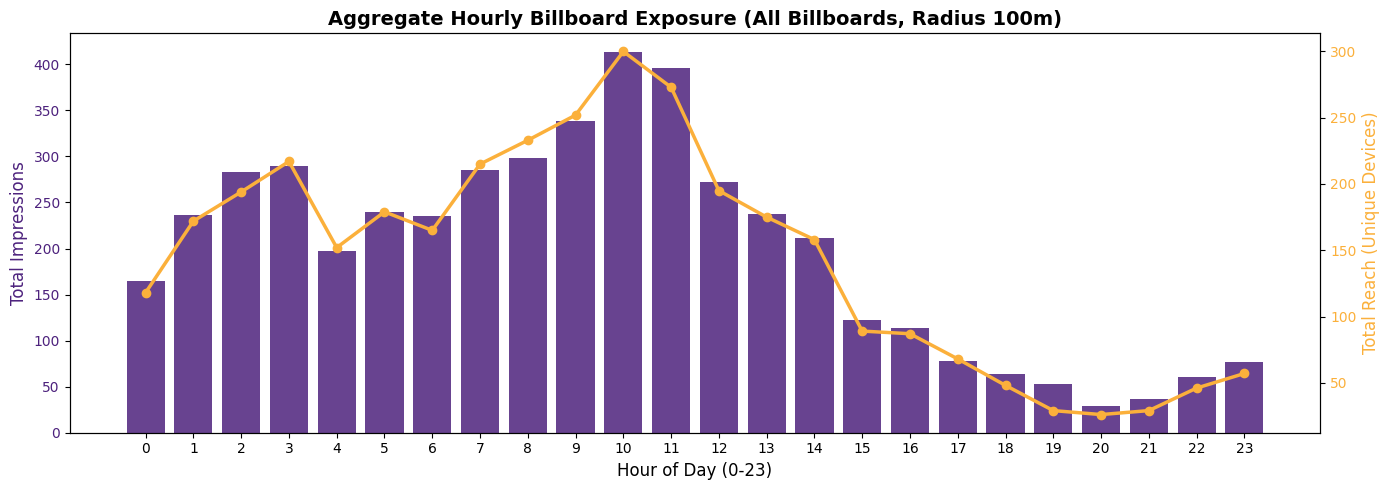

Peak exposure hour: 10 with 413 impressions
Lowest exposure hour: 20 with 29 impressions


In [35]:
query_hourly_agg = """
SELECT
  EXTRACT(HOUR FROM datetime) AS hour_of_day,
  COUNT(*) AS total_impressions,
  COUNT(DISTINCT device_id) AS total_reach
FROM `stickearn-test-502018.stickearn_test.exposure_proximity`
WHERE within_100m = TRUE
GROUP BY hour_of_day
ORDER BY hour_of_day
"""
df_hourly_agg = client.query(query_hourly_agg).to_dataframe()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(df_hourly_agg['hour_of_day'], df_hourly_agg['total_impressions'], color=color1, alpha=0.85, label='Total Impressions')
ax1.set_xlabel('Hour of Day (0-23)', fontsize=12)
ax1.set_ylabel('Total Impressions', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(df_hourly_agg['hour_of_day'], df_hourly_agg['total_reach'], color=color2, marker='o', linewidth=2.5, label='Total Reach')
ax2.set_ylabel('Total Reach (Unique Devices)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Aggregate Hourly Billboard Exposure (All Billboards, Radius 100m)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('hourly_exposure_aggregate.png', dpi=150, bbox_inches='tight')
plt.show()

peak = df_hourly_agg.loc[df_hourly_agg['total_impressions'].idxmax()]
low = df_hourly_agg.loc[df_hourly_agg['total_impressions'].idxmin()]
print(f"Peak exposure hour: {int(peak['hour_of_day'])} with {int(peak['total_impressions'])} impressions")
print(f"Lowest exposure hour: {int(low['hour_of_day'])} with {int(low['total_impressions'])} impressions")

## Hourly Exposure by Billboard Category

In [36]:
query_hourly_billboard = """
SELECT
  billboard_id,
  billboard_name,
  EXTRACT(HOUR FROM datetime) AS hour_of_day,
  COUNT(*) AS impressions,
  COUNT(DISTINCT device_id) AS reach
FROM `stickearn-test-502018.stickearn_test.exposure_proximity`
WHERE within_100m = TRUE
GROUP BY billboard_id, billboard_name, hour_of_day
ORDER BY billboard_id, hour_of_day
"""
df_hourly_billboard = client.query(query_hourly_billboard).to_dataframe()

# Merge with classification from Stage 3 (df_100m)
df_hourly_merged = df_hourly_billboard.merge(
    df_100m[['billboard_id', 'classification']],
    on='billboard_id',
    how='left'
)

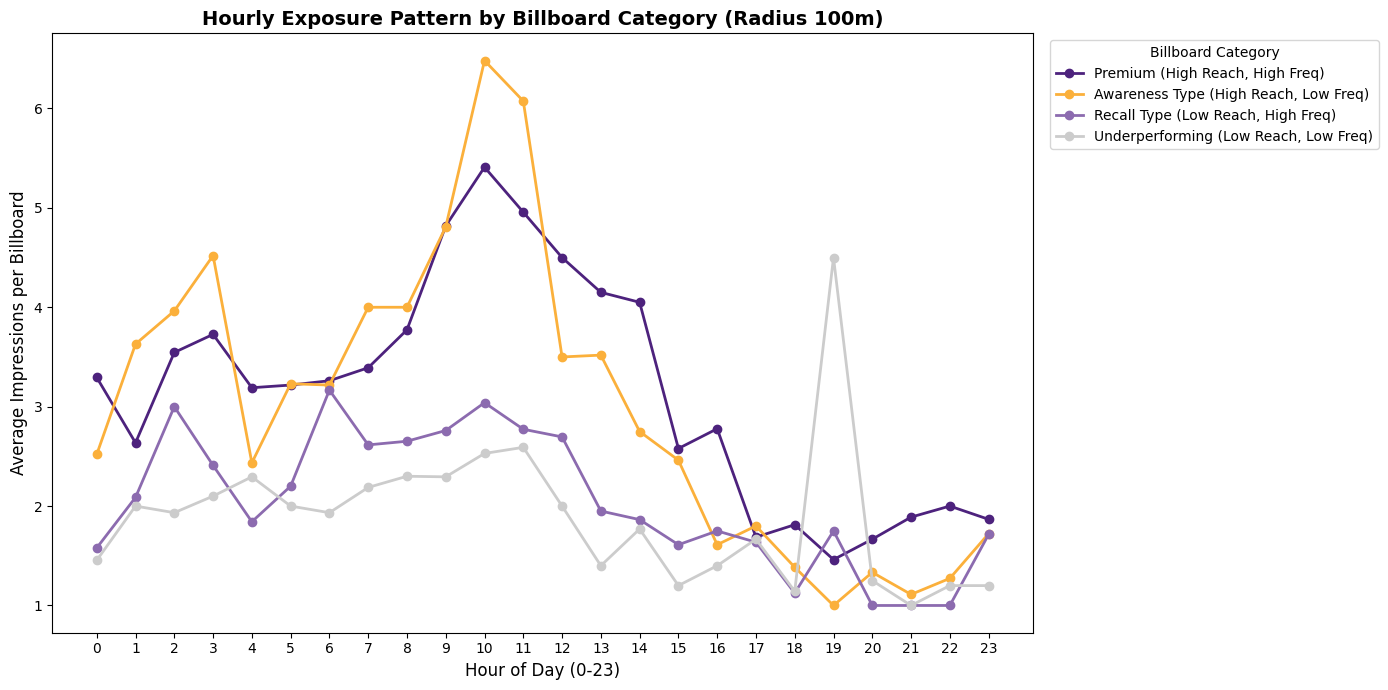

In [37]:
df_category_hourly = (
    df_hourly_merged
    .groupby(['classification', 'hour_of_day'])['impressions']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
for category, color in category_colors.items():
    subset = df_category_hourly[df_category_hourly['classification'] == category]
    ax.plot(subset['hour_of_day'], subset['impressions'], marker='o', linewidth=2,
            label=category, color=color)

ax.set_xlabel('Hour of Day (0-23)', fontsize=12)
ax.set_ylabel('Average Impressions per Billboard', fontsize=12)
ax.set_title('Hourly Exposure Pattern by Billboard Category (Radius 100m)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(title='Billboard Category', loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('hourly_exposure_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print("\n=== Peak Hour per Billboard Category ===")
for category in category_colors.keys():
    subset = df_category_hourly[df_category_hourly['classification'] == category]
    if len(subset) > 0:
        peak_row = subset.loc[subset['impressions'].idxmax()]
        print(f"{category}: peak at hour {int(peak_row['hour_of_day'])} "
              f"({peak_row['impressions']:.2f} avg impressions)")


=== Peak Hour per Billboard Category ===
Premium (High Reach, High Freq): peak at hour 10 (5.41 avg impressions)
Awareness Type (High Reach, Low Freq): peak at hour 10 (6.48 avg impressions)
Recall Type (Low Reach, High Freq): peak at hour 6 (3.17 avg impressions)
Underperforming (Low Reach, Low Freq): peak at hour 19 (4.50 avg impressions)


In [39]:
# Filter specifically for billboards classified as Underperforming
underperforming_ids = df_100m[df_100m['classification'] == 'Underperforming (Low Reach, Low Freq)']['billboard_id']

# Get per-billboard detail at hour 19, for Underperforming billboards only
df_underperforming_hour19 = df_hourly_merged[
    (df_hourly_merged['classification'] == 'Underperforming (Low Reach, Low Freq)') &
    (df_hourly_merged['hour_of_day'] == 19)
][['billboard_id', 'billboard_name', 'impressions']].sort_values('impressions', ascending=False)

print(f"Total billboards in Underperforming category: {len(underperforming_ids)}")
print(f"Number of Underperforming billboards with data at hour 19: {len(df_underperforming_hour19)}")
print(f"\n=== Underperforming Billboards at Hour 19 (Detail) ===")
print(df_underperforming_hour19.to_string(index=False))

print(f"\nAverage impressions at hour 19 (Underperforming only): {df_underperforming_hour19['impressions'].mean():.2f}")
print(f"Sum check (should match chart's data source): {df_underperforming_hour19['impressions'].sum()}")

Total billboards in Underperforming category: 23
Number of Underperforming billboards with data at hour 19: 4

=== Underperforming Billboards at Hour 19 (Detail) ===
                        billboard_id                        billboard_name  impressions
87160c4f-731d-11ee-a8b9-42010a94000b    Jl. Apel 1 Blok A1 No.10  - Bekasi            6
871deb20-731d-11ee-a8b9-42010a94000b   Jl. Apel 1 Blok A1 No.10 A - Bekasi            6
d868c280-dd0a-41fd-84d5-fb525e589823      Jl. Raya Jatimekar No.36J Bekasi            5
dad77fec-6c0f-11ee-a8b9-42010a94000b Jl. Kamal Muara No.88 - Jakarta Utara            1

Average impressions at hour 19 (Underperforming only): 4.50
Sum check (should match chart's data source): 18


# Opportunity

In [40]:
# df_grid was already fetched earlier in the Mobility Activity section;
# reused here for the Opportunity Gap map (no need to re-query)

query_billboard = """
SELECT uuid AS billboard_id, name AS billboard_name, latitude, longitude
FROM `stickearn-test-502018.stickearn_test.billboard_data`
"""
df_billboard = client.query(query_billboard).to_dataframe()

query_median_reach = """
SELECT
  APPROX_QUANTILES(reach, 100)[OFFSET(50)] AS median_reach
FROM (
  SELECT billboard_id, COUNT(DISTINCT device_id) AS reach
  FROM `stickearn-test-502018.stickearn_test.exposure_proximity`
  WHERE within_100m = TRUE
  GROUP BY billboard_id
)
"""
median_reach = client.query(query_median_reach).to_dataframe()['median_reach'][0]
print(f"Median reach across billboards: {median_reach}")

query_top_gap = f"""
SELECT grid_lat, grid_long, point_count, unique_devices, distance_to_nearest_billboard
FROM `stickearn-test-502018.stickearn_test.opportunity_gap`
WHERE is_opportunity_gap = TRUE
ORDER BY point_count DESC
LIMIT 30
"""
df_top_gap = client.query(query_top_gap).to_dataframe()

Median reach across billboards: 37


In [41]:
df_top_gap['gap_category'] = df_top_gap['distance_to_nearest_billboard'].apply(
    lambda d: 'Near-field (500-1500m)' if d <= 1500
    else ('Far-field (>3000m)' if d > 3000 else 'Mid-range (1500-3000m)')
)

## Mobility density

In [42]:
fig = go.Figure()

df_grid_top = df_grid.sort_values('point_count', ascending=False).head(1500)

fig.add_trace(go.Scattermapbox(
    lat=df_grid_top['grid_lat'],
    lon=df_grid_top['grid_long'],
    mode='markers',
    marker=dict(
        size=6,
        color=df_grid_top['point_count'],
        colorscale='Purples',
        opacity=0.5,
        colorbar=dict(title='Mobility Density', x=1.02)
    ),
    name='Mobility Density (Top 1500 Grid)',
    hovertemplate='Point Count: %{marker.color}<extra></extra>'
))

# Layer 2: Existing billboard locations
fig.add_trace(go.Scattermapbox(
    lat=df_billboard['latitude'],
    lon=df_billboard['longitude'],
    mode='markers',
    marker=dict(size=8, color=color1, symbol='circle'),
    name='Existing Billboard',
    text=df_billboard['billboard_name'],
    hovertemplate='%{text}<extra></extra>'
))

# Layer 3: Top opportunity gap zones (highlighted, high density + far from billboard)
fig.add_trace(go.Scattermapbox(
    lat=df_top_gap['grid_lat'],
    lon=df_top_gap['grid_long'],
    mode='markers',
    marker=dict(size=16, color=color2, symbol='circle'),
    name='Top Opportunity Gap Zone',
    text=[f"Point Count: {pc} | Distance to Nearest Billboard: {d:.0f}m"
          for pc, d in zip(df_top_gap['point_count'], df_top_gap['distance_to_nearest_billboard'])],
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        center=dict(lat=-6.2, lon=106.816),
        zoom=10
    ),
    title="Mobility Density, Existing Billboard, & Top Opportunity Gap Zones",
    width=950, height=750,
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)')
)
fig.show()
fig.write_html("opportunity_gap_map.html")